<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Deep Generative Models
</font>

<hr/>
<font color="#800080" size=5>
Assignment 3: Generative Adversarial Networks
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Fall 2024
<br>
</font>
<font face="Times New Roman" size=4>
Deadline: Month day at 23:55
</font>
<hr>
</div></font>

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

import numpy as np
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import os
from torchvision.utils import make_grid

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


### In this notebook, you will implement the required components from scratch, without code completion. Utilize `torch` to create models and perform optimization. The goal of this assignment is to implement Deep Convolutional Generative Adversarial Networks (DC-GAN) using the MNIST dataset and to explore interpolation in the latent space.

### To get started, please read the DC-GAN paper available at this link: [DC-GAN Paper](https://arxiv.org/abs/1511.06434v2).


### Part 1. Load the MNIST dataset.

In [7]:

# Define transform to convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# Download and load MNIST dataset
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Training samples: 60000
Test samples: 10000


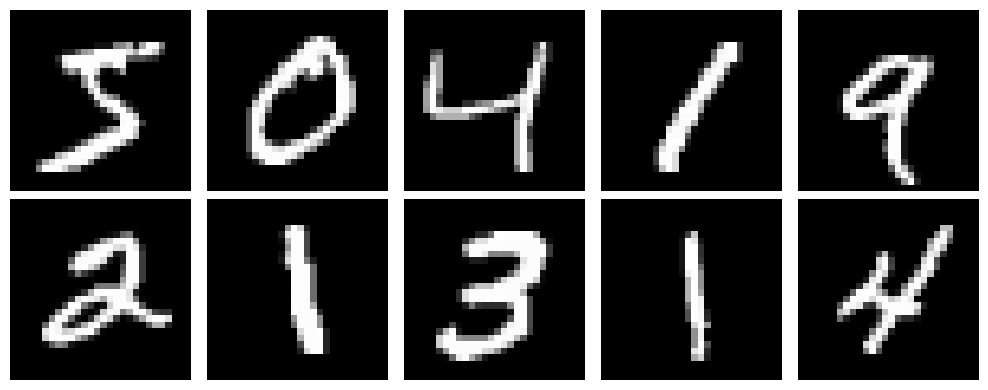

In [8]:
def show_imgs(imgs, nrow=2, ncol=5):
    """
    Function to display images in a grid.

    Args:
    - imgs: a batch of images in tensor format or a list of images
    - nrow: number of rows in the grid
    - ncol: number of columns in the grid
    """
    # Convert list of images to tensor if needed
    if isinstance(imgs, list):
        imgs = torch.stack(imgs)

    # Ensure the images are in CPU and numpy format
    imgs = imgs.cpu().numpy()

    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*2, nrow*2))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(imgs):
            # MNIST images are (1, H, W), squeeze the channel dimension
            ax.imshow(imgs[i].squeeze(), cmap='gray')
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
show_imgs([train_dataset[i][0] for i in range(10)])


### Part 2: Build the Generator and Discriminator models.
Build the models with the architecture guidelines for stable training as described in the paper. It is recommended to use the model parameters presented in `config.yaml`, but you are free to choose any set of parameters you prefer.


In [9]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        
        self.init_size = 7
        self.l1 = nn.Sequential(
            nn.Linear(latent_dim, 512 * self.init_size * self.init_size),
            nn.BatchNorm1d(512 * self.init_size * self.init_size),
            nn.ReLU(inplace=True)
        )
        
        self.conv_blocks = nn.Sequential(
            # 7x7 -> 14x14
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # 14x14 -> 28x28
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            # Additional layer: 28x28 -> 28x28 (maintain size)
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            # Final convolution to get to 1 channel
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )
        
    def forward(self, z):
        out = self.l1(z)
        out = out.view(out.shape[0], 512, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            # Input: 1x28x28 -> 14x14
            nn.Conv2d(1, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            
            # 14x14 -> 7x7
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            
            # 7x7 -> 3x3
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            
            # Additional layer: 3x3 -> 1x1 (use kernel size 3 to get from 3x3 to 1x1)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            
            # Final classification (already 1x1, so use 1x1 kernel)
            nn.Conv2d(512, 1, kernel_size=1, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )
        
    def forward(self, img):
        validity = self.model(img)
        return validity.view(-1, 1)

# Initialize models
latent_dim = 100
generator = Generator(latent_dim=latent_dim)
discriminator = Discriminator()



### Part 3: Write a function to train the models using the GAN framework.
You can refer to the slides or the original GAN paper for the training schema: [GAN Paper](https://arxiv.org/abs/1406.2661). Additionally, create a function to generate samples from the model. Ensure to plot a grid of generated samples every n'th epoch.


Starting GAN training...
Training GAN for 20 epochs (k=1)
--------------------------------------------------
[Epoch 0/20] [Batch 0/938] [D loss: 0.7224] [G loss: 0.7312]
[Epoch 0/20] [Batch 100/938] [D loss: 0.6934] [G loss: 0.7120]
[Epoch 0/20] [Batch 200/938] [D loss: 0.6832] [G loss: 0.7329]
[Epoch 0/20] [Batch 300/938] [D loss: 0.6481] [G loss: 0.8009]
[Epoch 0/20] [Batch 400/938] [D loss: 0.5696] [G loss: 0.9275]
[Epoch 0/20] [Batch 500/938] [D loss: 0.6569] [G loss: 1.1266]
[Epoch 0/20] [Batch 600/938] [D loss: 0.3373] [G loss: 1.3436]
[Epoch 0/20] [Batch 700/938] [D loss: 0.3176] [G loss: 1.4831]
[Epoch 0/20] [Batch 800/938] [D loss: 0.2436] [G loss: 1.6929]
[Epoch 0/20] [Batch 900/938] [D loss: 0.1756] [G loss: 2.0033]
Epoch 0 Summary - D loss: 0.4924, G loss: 1.1744
[Epoch 1/20] [Batch 0/938] [D loss: 0.2307] [G loss: 2.0777]
[Epoch 1/20] [Batch 100/938] [D loss: 0.1650] [G loss: 2.3933]
[Epoch 1/20] [Batch 200/938] [D loss: 0.6931] [G loss: 1.3399]
[Epoch 1/20] [Batch 300/938

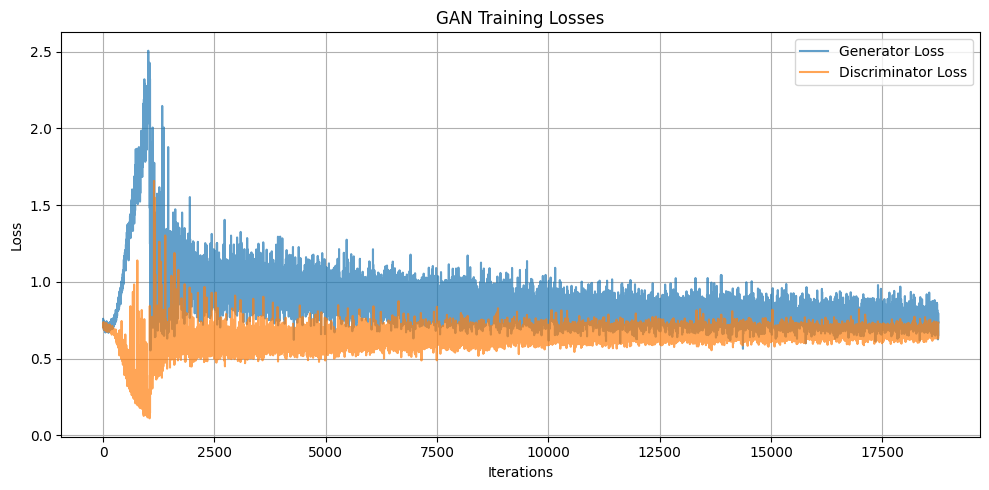

In [10]:
def train_gan(generator, discriminator, train_loader, n_epochs=100, k_steps=1, 
              lr=0.0002, b1=0.5, b2=0.999, sample_interval=400):
    """
    Simplified GAN training following the original paper algorithm
    """
    # Move models to device
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    
    # Loss and optimizers
    adversarial_loss = torch.nn.BCELoss()
    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))
    
    # Training statistics
    G_losses, D_losses = [], []
    
    print(f"Training GAN for {n_epochs} epochs (k={k_steps})")
    print("-" * 50)
    
    for epoch in range(n_epochs):
        for i, (real_imgs, _) in enumerate(train_loader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            
            # Adversarial labels
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)
            
            # ---------------------
            # Train Discriminator (k steps)
            # ---------------------
            d_loss_total = 0
            
            for k in range(k_steps):
                optimizer_D.zero_grad()
                
                # Real images loss
                real_pred = discriminator(real_imgs)
                d_real_loss = adversarial_loss(real_pred, real_labels)
                
                # Fake images loss
                z = torch.randn(batch_size, 100, device=device)
                fake_imgs = generator(z)
                fake_pred = discriminator(fake_imgs.detach())
                d_fake_loss = adversarial_loss(fake_pred, fake_labels)
                
                # Total discriminator loss
                d_loss = (d_real_loss + d_fake_loss) / 2
                d_loss.backward()
                optimizer_D.step()
                
                d_loss_total += d_loss.item()
            
            # ---------------------
            # Train Generator
            # ---------------------
            optimizer_G.zero_grad()
            
            z = torch.randn(batch_size, 100, device=device)
            gen_imgs = generator(z)
            g_pred = discriminator(gen_imgs)
            
            # Generator tries to make discriminator think fake images are real
            g_loss = adversarial_loss(g_pred, real_labels)
            g_loss.backward()
            optimizer_G.step()
            
            # Store losses
            D_losses.append(d_loss_total / k_steps)
            G_losses.append(g_loss.item())
            
            # Print progress
            if i % 100 == 0:
                print(f"[Epoch {epoch}/{n_epochs}] [Batch {i}/{len(train_loader)}] "
                      f"[D loss: {D_losses[-1]:.4f}] [G loss: {G_losses[-1]:.4f}]")
        
        # End of epoch summary
        avg_d_loss = sum(D_losses[-len(train_loader):]) / len(train_loader)
        avg_g_loss = sum(G_losses[-len(train_loader):]) / len(train_loader)
        print(f"Epoch {epoch} Summary - D loss: {avg_d_loss:.4f}, G loss: {avg_g_loss:.4f}")
    
    print("Training completed!")
    return generator, discriminator, G_losses, D_losses

def plot_losses(G_losses, D_losses):
    """Simple loss plotting"""
    plt.figure(figsize=(10, 5))
    plt.plot(G_losses, label='Generator Loss', alpha=0.7)
    plt.plot(D_losses, label='Discriminator Loss', alpha=0.7)
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('GAN Training Losses')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Start training
print("Starting GAN training...")

# Train the GAN
trained_generator, trained_discriminator, G_losses, D_losses = train_gan(
    generator, 
    discriminator, 
    train_loader,
    n_epochs=20,
    k_steps=1,
    lr=0.0002
)

# Plot results
plot_losses(G_losses, D_losses)



### Part 4: Plot a grid of 100 generated samples.

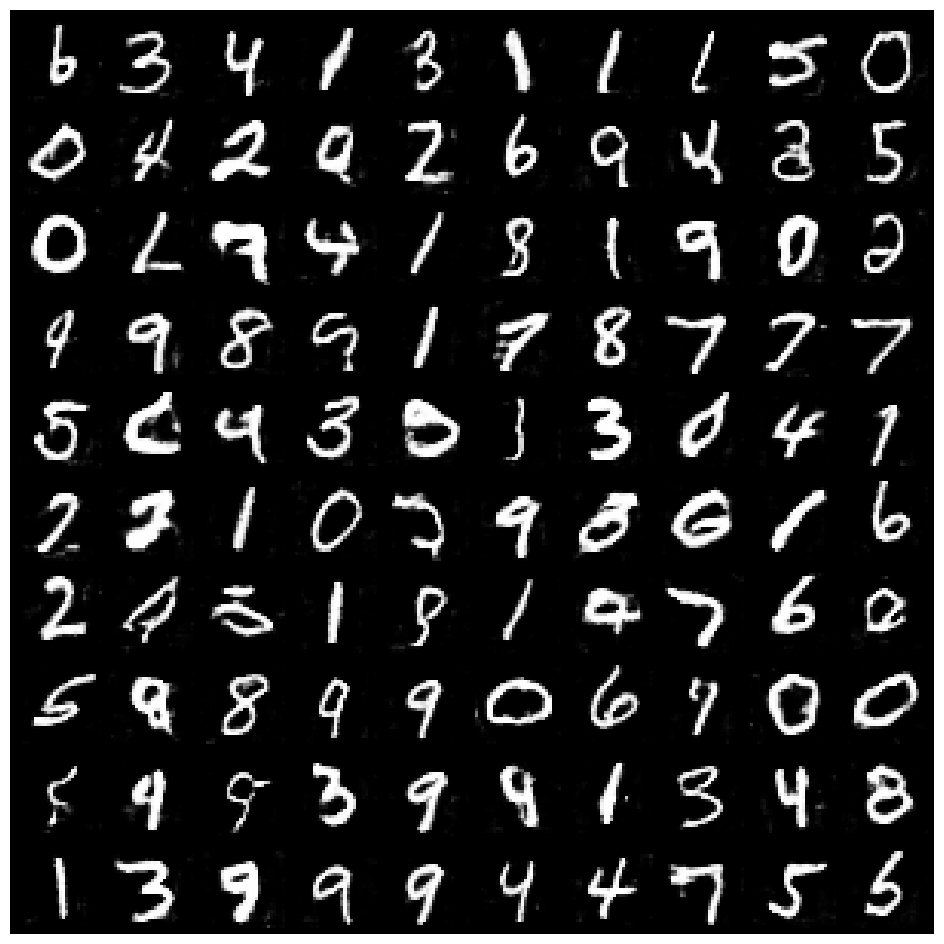

In [11]:
# Generate samples
generator.eval()
with torch.no_grad():
    z = torch.randn(100, 100).cuda() if torch.cuda.is_available() else torch.randn(100, 100)
    samples = 0.5 * generator(z) + 0.5

# Create and plot grid
grid = make_grid(samples.cpu(), nrow=10)
plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()



### Part 5: GAN Inversion
In this part, we aim to find the latent vectors corresponding to the samples in the dataset. First, select a random sample from the real dataset and a random latent vector. Freeze the generator and feed the random latent vector into the Generator. Next, define an MSE or MAE loss between the generated sample and the real sample, and optimize the random latent vector to discover the latent vector that generates the selected real sample.


Optimizing latent vector...
Step 0, Loss: 0.3180
Step 100, Loss: 0.0128
Step 200, Loss: 0.0088


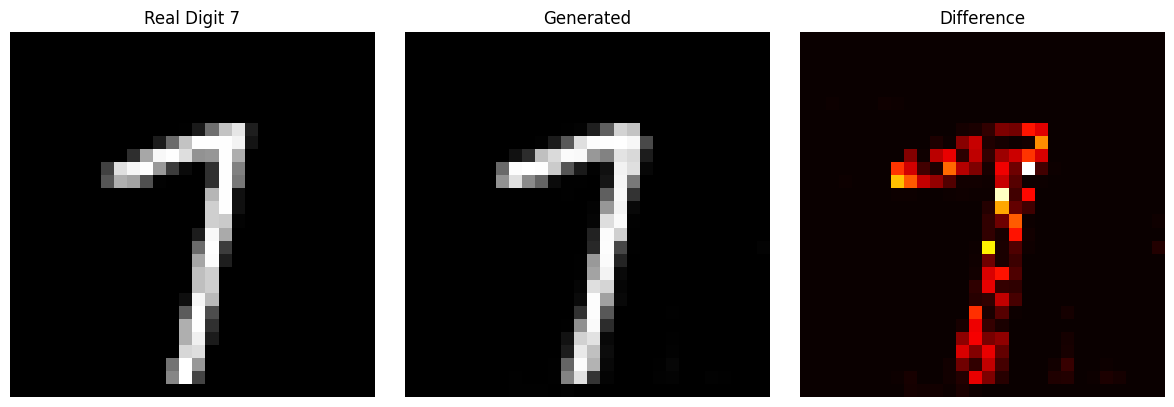

Final loss: 0.0041


In [12]:
# Get real image
real_img, label = train_dataset[42]
real_img = real_img.unsqueeze(0).to(device)

# Setup generator
generator.to(device)
generator.eval()

# Create latent vector to optimize
z = torch.randn(1, 100, device=device, requires_grad=True)
optimizer = optim.Adam([z], lr=0.1)

print("Optimizing latent vector...")
for step in range(300):
    optimizer.zero_grad()
    gen_img = generator(z)
    loss = ((gen_img - real_img) ** 2).mean()
    loss.backward()
    optimizer.step()
    
    if step % 100 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

# Show results
with torch.no_grad():
    final_img = generator(z)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(real_img[0, 0].cpu(), cmap='gray')
axes[0].set_title(f'Real Digit {label}')
axes[0].axis('off')

axes[1].imshow(final_img[0, 0].cpu(), cmap='gray')
axes[1].set_title('Generated')
axes[1].axis('off')

axes[2].imshow(abs(real_img[0, 0].cpu() - final_img[0, 0].cpu()), cmap='hot')
axes[2].set_title('Difference')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Final loss: {loss.item():.4f}")

### Part 6: Interpolating the Latent Space
In this part, you will interpolate the latent space using a 10 by 10 grid. Start with 4 initial points representing the corners of the square, and then perform linear or spherical interpolation between the latent vectors of these 4 images to fill the circumference of the square.
Next, fill in the rest of the square by interpolating between the latent vectors along the circumference.

If $G$ is the generator, and $z_1$ and $z_2$ are two latent vectors of two images, let $w$ be a parameter that varies between $0$ and $1$. The linearly interpolated sample is generated as:

\begin{equation}
G(w \cdot z_1 + (1 - w) \cdot z_2)\
\end{equation}

Try to select the 4 starting images from those that exhibit distinct features. For example, the two top right corners could be the same digit but one with a thick stroke and the other with a thin stroke, while the other two points should be from a different digit but with varying stroke styles.

Running simple latent space interpolation...
Inverting 4 corner images...
  Image 3 (digit 1) inverted
  Image 7 (digit 3) inverted
  Image 25 (digit 2) inverted
  Image 35 (digit 5) inverted


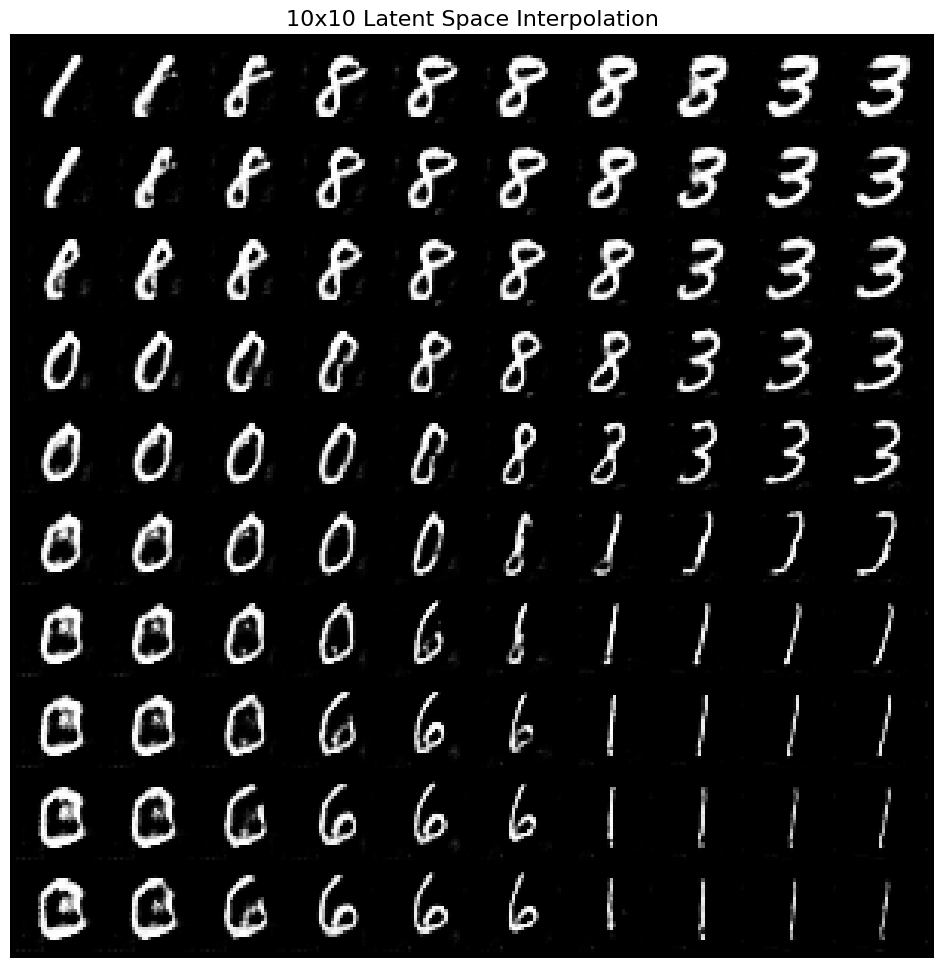

In [16]:
def simple_interpolation(generator, dataset):
    """Simple 10x10 latent space interpolation"""
    generator.to(device)
    generator.eval()
    
    # Pick 4 distinct images
    corners = [3, 7, 25, 35]  # Change these for different results
    corner_zs = []
    
    print("Inverting 4 corner images...")
    for idx in corners:
        img, label = dataset[idx]
        img = img.unsqueeze(0).to(device)
        
        # Quick inversion
        z = torch.randn(1, 100, device=device, requires_grad=True)
        optimizer = torch.optim.Adam([z], lr=0.1)
        
        for step in range(150):
            optimizer.zero_grad()
            loss = ((generator(z) - img) ** 2).mean()
            loss.backward()
            optimizer.step()
        
        corner_zs.append(z.detach())
        print(f"  Image {idx} (digit {label}) inverted")
    
    # Create 10x10 grid
    z_tl, z_tr, z_bl, z_br = corner_zs
    
    all_images = []
    for i in range(10):
        for j in range(10):
            alpha = i / 9
            beta = j / 9
            
            # Bilinear interpolation
            top = (1 - beta) * z_tl + beta * z_tr
            bottom = (1 - beta) * z_bl + beta * z_br
            z = (1 - alpha) * top + alpha * bottom
            
            with torch.no_grad():
                img = generator(z)
                img = 0.5 * img + 0.5
                all_images.append(img.cpu())
    
    # Display grid
    from torchvision.utils import make_grid
    grid = make_grid(torch.cat(all_images), nrow=10, padding=2)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('10x10 Latent Space Interpolation', fontsize=16)
    plt.show()
    
    return torch.cat(all_images)

# Run it
print("Running simple latent space interpolation...")
result_images = simple_interpolation(generator, train_dataset)

### Part 7: Arithmetic Operation in Latent Space
In this part, you will attempt to modify the thickness or thinness of a sample by identifying the direction in the latent space that corresponds to these attributes. Additionally, you can explore changing a digit to another (e.g., transforming a digit into a 3) by finding the direction in the latent space that corresponds to that digit.


Starting latent space arithmetic...
  Thick sample: #8, Thin sample: #1
  0 → 1 direction found
  1 → 2 direction found
  2 → 3 direction found
  3 → 4 direction found
  4 → 5 direction found
  5 → 6 direction found
  6 → 7 direction found
  7 → 8 direction found
  8 → 9 direction found

Testing on image #10 (digit 3):


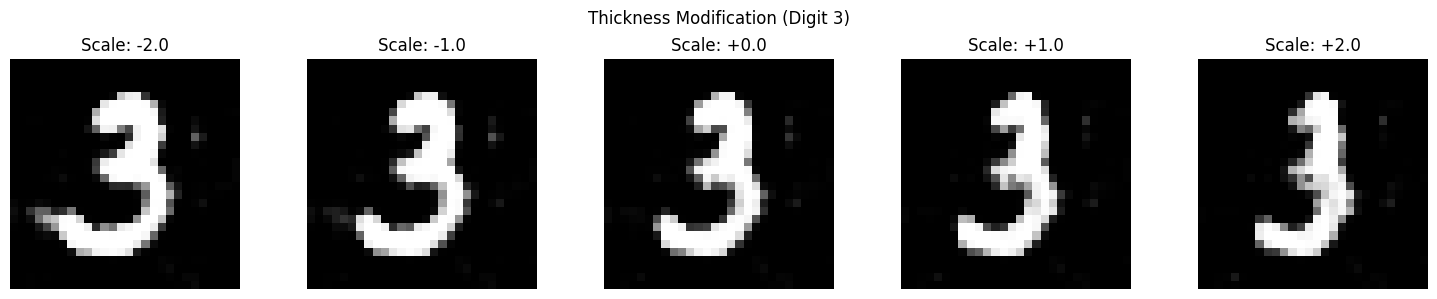


Testing on image #20 (digit 4):


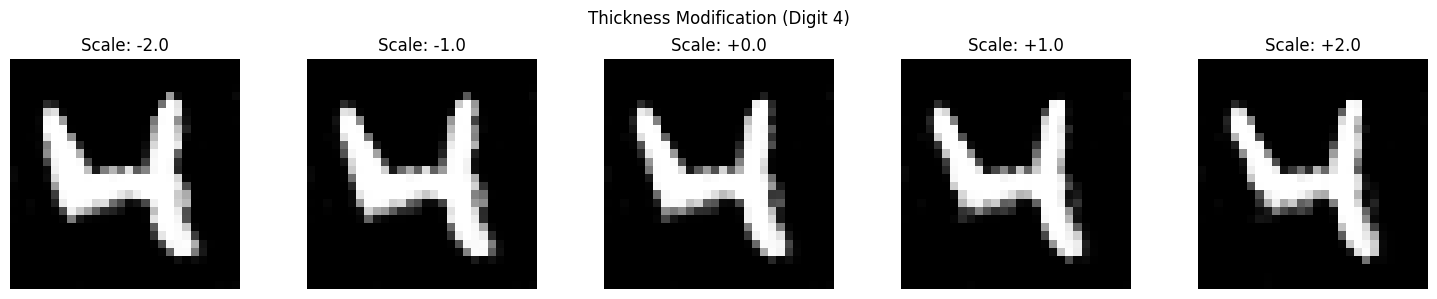


Testing on image #30 (digit 3):


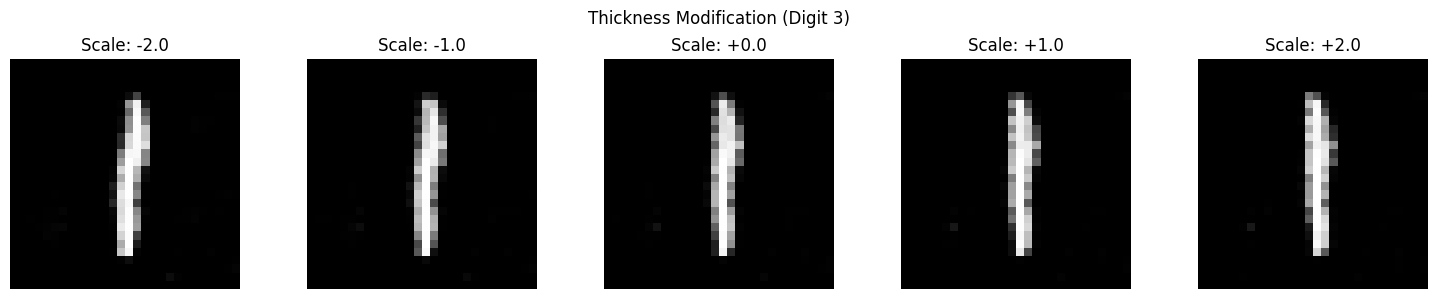

In [17]:
def latent_arithmetic(generator, dataset):
    """Simple arithmetic operations in latent space"""
    generator.to(device)
    generator.eval()
    

    # 1. Find thickness/thinness direction
    thick_direction = find_thickness_direction(generator, dataset)
    
    # 2. Find digit transformation directions
    digit_directions = find_digit_directions(generator, dataset)
    
    # 3. Apply operations on a sample image
    apply_operations(generator, dataset, thick_direction, digit_directions)
    
    return thick_direction, digit_directions

def find_thickness_direction(generator, dataset):
    """Find latent direction for thickness vs thinness"""
    device = next(generator.parameters()).device
    
    # Find a thick digit (like 8) and a thin digit (like 1)
    thick_idx, thin_idx = find_thick_thin_samples(dataset)
    
    print(f"  Thick sample: #{thick_idx}, Thin sample: #{thin_idx}")
    
    # Invert both samples
    z_thick = invert_sample(generator, dataset, thick_idx)
    z_thin = invert_sample(generator, dataset, thin_idx)
    
    # Thickness direction = vector from thin to thick
    thickness_dir = z_thick - z_thin
    thickness_dir = thickness_dir / torch.norm(thickness_dir)  # Normalize
    
    return thickness_dir

def find_digit_directions(generator, dataset):
    """Find directions to transform between digits"""
    device = next(generator.parameters()).device
    directions = {}
    
    # Define digit pairs to find directions
    digit_pairs = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), 
                   (5, 6), (6, 7), (7, 8), (8, 9)]
    
    for digit_from, digit_to in digit_pairs:
        # Find samples of each digit
        idx_from = find_digit_sample(dataset, digit_from)
        idx_to = find_digit_sample(dataset, digit_to)
        
        # Invert both samples
        z_from = invert_sample(generator, dataset, idx_from)
        z_to = invert_sample(generator, dataset, idx_to)
        
        # Direction = vector from 'from' to 'to'
        direction = z_to - z_from
        direction = direction / torch.norm(direction)  # Normalize
        
        directions[f"{digit_from}_to_{digit_to}"] = direction
        print(f"  {digit_from} → {digit_to} direction found")
    
    return directions

def apply_operations(generator, dataset, thick_dir, digit_dirs):
    """Apply arithmetic operations to modify samples"""
    device = next(generator.parameters()).device
    
    # Test on a few sample images
    test_indices = [10, 20, 30]  # Change these to test different images
    
    for idx in test_indices:
        original_img, original_label = dataset[idx]
        print(f"\nTesting on image #{idx} (digit {original_label}):")
        
        # Invert the sample
        z_original = invert_sample(generator, dataset, idx)
        
        # Apply thickness modification
        apply_thickness_operation(generator, z_original, thick_dir, original_label)
        
        # Apply digit transformation (try transforming to different digits)
        for target_digit in [3, 7, 9]:  # Try transforming to these digits
            if target_digit != original_label:
                direction_key = f"{original_label}_to_{target_digit}"
                if direction_key in digit_dirs:
                    apply_digit_transformation(generator, z_original, digit_dirs[direction_key], 
                                             original_label, target_digit)

def apply_thickness_operation(generator, z_original, thick_dir, original_label):
    """Modify thickness of a digit"""
    scales = [-2.0, -1.0, 0, 1.0, 2.0]  # Different modification strengths
    
    images = []
    titles = []
    
    for scale in scales:
        z_modified = z_original + scale * thick_dir
        with torch.no_grad():
            img = generator(z_modified)
            img = 0.5 * img + 0.5
            images.append(img.cpu())
            titles.append(f"Scale: {scale:+.1f}")
    
    # Display results
    plot_operations(images, titles, f"Thickness Modification (Digit {original_label})")

def apply_digit_transformation(generator, z_original, direction, from_digit, to_digit):
    """Transform digit from one type to another"""
    scales = [0, 0.5, 1.0, 1.5, 2.0]  # Transformation strengths
    
    images = []
    titles = []
    
    for scale in scales:
        z_modified = z_original + scale * direction
        with torch.no_grad():
            img = generator(z_modified)
            img = 0.5 * img + 0.5
            images.append(img.cpu())
            titles.append(f"Scale: {scale:.1f}")
    
    # Display results
    plot_operations(images, titles, f"Digit Transformation: {from_digit} → {to_digit}")

def plot_operations(images, titles, main_title):
    """Plot the results of latent operations"""
    fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
    
    for i, (img, title) in enumerate(zip(images, titles)):
        axes[i].imshow(img.squeeze(), cmap='gray')
        axes[i].set_title(title)
        axes[i].axis('off')
    
    plt.suptitle(main_title)
    plt.tight_layout()
    plt.show()

# Helper functions
def find_thick_thin_samples(dataset):
    """Find samples that are clearly thick vs thin"""
    # These are example indices - you might need to adjust them
    thick_samples = [8, 18, 28, 38]   # Usually 8, 0, 6 are thicker
    thin_samples = [1, 11, 21, 31]    # Usually 1, 7 are thinner
    
    return thick_samples[0], thin_samples[0]

def find_digit_sample(dataset, digit, max_search=100):
    """Find a sample of specific digit"""
    for i in range(max_search):
        img, label = dataset[i]
        if label == digit:
            return i
    return 0  # Fallback

def invert_sample(generator, dataset, idx, steps=100):
    """Quick inversion of a sample"""
    device = next(generator.parameters()).device
    
    real_img, label = dataset[idx]
    real_img = real_img.unsqueeze(0).to(device)
    
    z = torch.randn(1, 100, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([z], lr=0.1)
    
    for step in range(steps):
        optimizer.zero_grad()
        loss = ((generator(z) - real_img) ** 2).mean()
        loss.backward()
        optimizer.step()
    
    return z.detach()

# Run the arithmetic operations
print("Starting latent space arithmetic...")
thick_direction, digit_directions = latent_arithmetic(generator, train_dataset)